# Entender `PageHinkleyDetector` paso a paso

Este notebook explica la implementacion real de `src/retail_forecasting/drift/detectors.py`.

El objetivo no es solo ver la idea general del detector, sino entender exactamente:

- que estado interno mantiene
- que hace `update(error)` en cada paso
- como se interpreta `score`
- cuando se dispara `is_drift = True`
- como encaja con el uso del proyecto sobre `MAE` por fold


In [1]:
from __future__ import annotations

from pathlib import Path
import inspect
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

from retail_forecasting.drift.detectors import PageHinkleyDetector


## 1. La implementacion real del proyecto

Lo primero importante: el detector del repo esta inspirado en Page-Hinkley, pero no es una transliteracion academica exacta. Esta orientado a detectar degradacion del error del modelo.

Por eso este notebook estudia la implementacion real, no una version teorica distinta.


In [2]:
print(inspect.getsource(PageHinkleyDetector))


class PageHinkleyDetector:
    """Implementation of the Page-Hinkley test for concept drift detection.

    The Page-Hinkley (PH) test is a sequential analysis technique used for
    monitoring change point detection. It is designed to detect a change in
    the mean of a Gaussian signal.

    In the context of forecasting, we use it to monitor the model error.
    An increase in the cumulative deviation of the error suggests that
    the model's performance is degrading (Concept Drift).
    """

    def __init__(
        self, threshold: float = 30.0, delta: float = 0.005, min_instances: int = 30
    ):
        """Initialize the detector.

        Args:
            threshold: Cumulative deviation threshold (lambda). Higher values
                make the detector more robust to noise but slower to detect.
            delta: Magnitude of changes that are allowed.
            min_instances: Minimum number of samples before detecting drift.
        """
        self.threshold = threshold


## 2. Intuicion del detector

En este proyecto, al detector le van entrando errores secuenciales, por ejemplo un `MAE` por fold:

```text
fold 0 -> 3.1
fold 1 -> 3.0
fold 2 -> 3.2
fold 3 -> 5.4
fold 4 -> 5.8
```

La intuicion es:

- si el error se mantiene estable, el `score` del detector no crece mucho
- si el error empieza a subir de forma sostenida, el `score` acumula evidencia
- si el `score` supera `threshold`, se declara drift

Los parametros principales son:

- `threshold`: cuanta evidencia acumulada hace falta para disparar drift
- `delta`: pequena tolerancia para ignorar cambios minimos
- `min_instances`: cuantas observaciones minimas deben verse antes de poder detectar


## 3. Funcion auxiliar para trazar el estado interno

La clase del repo no expone toda la traza historica, asi que construimos una funcion de apoyo que ejecuta el detector paso a paso y guarda el estado tras cada `update()`.


In [3]:
def trace_page_hinkley(
    errors: list[float] | np.ndarray,
    *,
    threshold: float = 15.0,
    delta: float = 0.005,
    min_instances: int = 2,
) -> pd.DataFrame:
    detector = PageHinkleyDetector(
        threshold=threshold,
        delta=delta,
        min_instances=min_instances,
    )

    rows: list[dict[str, float | int | bool | None]] = []
    raw_error_sum = 0.0

    for i, error in enumerate(errors, start=1):
        avg_error_before_update = raw_error_sum / i
        raw_error_sum += float(error)

        result = detector.update(float(error))

        rows.append(
            {
                "index": i,
                "error": float(error),
                "avg_error_used": avg_error_before_update,
                "sum_errors": detector.sum_errors,
                "min_sum_errors": detector.min_sum_errors,
                "ph_stat": result.score,
                "threshold": result.threshold,
                "is_drift": result.is_drift,
                "detected_at_index": result.detected_at_index,
            }
        )

    return pd.DataFrame(rows)


## 4. Ejemplo pequeno, calculado paso a paso

Primero usamos una serie corta para entender el mecanismo. Bajamos el `threshold` para que el drift se vea pronto.


In [4]:
toy_errors = [3.0, 3.1, 3.0, 5.5, 5.8, 6.0]
toy_trace = trace_page_hinkley(
    toy_errors,
    threshold=4.0,
    delta=0.005,
    min_instances=2,
)
toy_trace


,index,error,avg_error_used,sum_errors,min_sum_errors,ph_stat,threshold,is_drift,detected_at_index
0,1,3.0,0.000000,5.995000,0.0,5.995000,4.0,False,NaN
1,2,3.1,1.500000,9.192500,0.0,9.192500,4.0,False,NaN
2,3,3.0,2.033333,12.123333,0.0,12.123333,4.0,True,3.0
3,4,5.5,2.275000,20.087500,0.0,20.087500,4.0,True,4.0
4,5,5.8,2.920000,27.665000,0.0,27.665000,4.0,True,5.0
5,6,6.0,3.400000,35.049167,0.0,35.049167,4.0,True,6.0


### Como leer la tabla

- `error`: la observacion nueva que entra al detector
- `avg_error_used`: la media historica usada como referencia en ese paso
- `sum_errors`: acumulador interno del detector tras el `update()`
- `min_sum_errors`: minimo historico alcanzado por ese acumulador
- `ph_stat`: la estadistica de decision `sum_errors - min_sum_errors`
- `is_drift`: si en ese paso se supera el umbral

Lo importante es que cuando los errores grandes llegan de forma sostenida, `ph_stat` empieza a crecer.


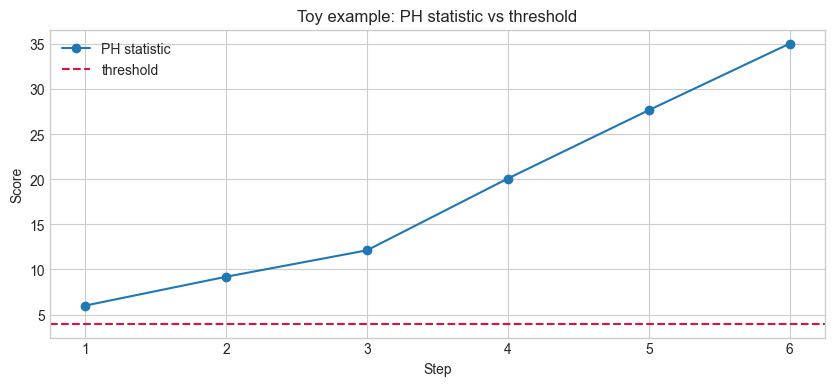

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(toy_trace["index"], toy_trace["ph_stat"], marker="o", label="PH statistic")
ax.axhline(toy_trace["threshold"].iloc[0], color="crimson", linestyle="--", label="threshold")
ax.set_title("Toy example: PH statistic vs threshold")
ax.set_xlabel("Step")
ax.set_ylabel("Score")
ax.legend()
plt.show()


## 5. Simulacion mas realista: error estable y luego degradacion

Ahora construimos una secuencia mas larga. Primero el error oscila alrededor de un nivel estable y despues cambia de regimen.


In [6]:
rng = np.random.default_rng(42)
stable_block = rng.normal(loc=3.0, scale=0.15, size=25)
drift_block = rng.normal(loc=5.2, scale=0.2, size=20)
simulated_errors = np.concatenate([stable_block, drift_block])

trace = trace_page_hinkley(
    simulated_errors,
    threshold=8.0,
    delta=0.01,
    min_instances=5,
)

trace.head()


,index,error,avg_error_used,sum_errors,min_sum_errors,ph_stat,threshold,is_drift,detected_at_index
0,1,3.045708,0.000000,6.081415,0.0,6.081415,8.0,False,NaN
1,2,2.844002,1.522854,8.718712,0.0,8.718712,8.0,False,NaN
2,3,3.112568,1.963237,12.027610,0.0,12.027610,8.0,False,NaN
3,4,3.141085,2.250569,15.292877,0.0,15.292877,8.0,False,NaN
4,5,2.707345,2.428672,17.638991,0.0,17.638991,8.0,False,NaN


In [7]:
drift_rows = trace[trace["is_drift"]]
detected_index = None if drift_rows.empty else int(drift_rows.iloc[0]["index"])
detected_index


6

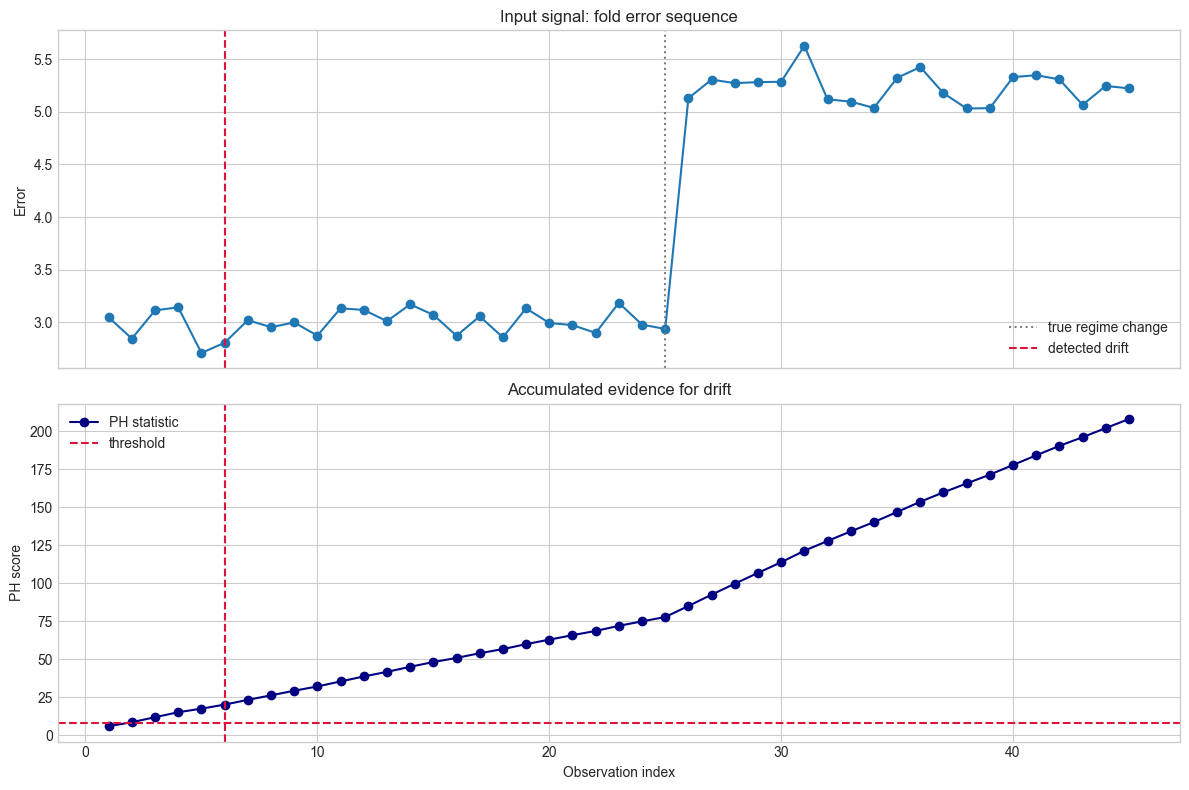

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(trace["index"], trace["error"], marker="o", linewidth=1.5)
axes[0].axvline(25, color="gray", linestyle=":", label="true regime change")
if detected_index is not None:
    axes[0].axvline(detected_index, color="crimson", linestyle="--", label="detected drift")
axes[0].set_title("Input signal: fold error sequence")
axes[0].set_ylabel("Error")
axes[0].legend()

axes[1].plot(trace["index"], trace["ph_stat"], marker="o", color="navy", label="PH statistic")
axes[1].axhline(trace["threshold"].iloc[0], color="crimson", linestyle="--", label="threshold")
if detected_index is not None:
    axes[1].axvline(detected_index, color="crimson", linestyle="--")
axes[1].set_title("Accumulated evidence for drift")
axes[1].set_xlabel("Observation index")
axes[1].set_ylabel("PH score")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Que hace exactamente `update(error)`

Si quieres leer la implementacion operativamente, cada paso hace esto:

1. incrementa `n`
2. calcula una media historica aproximada `avg_error`
3. actualiza `sum_errors`
4. calcula la desviacion `error - avg_error - delta`
5. vuelve a acumular esa desviacion en `sum_errors`
6. actualiza `min_sum_errors` si cae a un minimo nuevo
7. calcula `ph_stat = sum_errors - min_sum_errors`
8. si `n > min_instances` y `ph_stat > threshold`, dispara drift

Hay un detalle importante: la implementacion del repo usa una version simplificada y orientada a degradacion del error. No intenta detectar cualquier cambio de distribucion, sino aumentos persistentes en la senal monitorizada.


## 7. Conexion directa con el pipeline del proyecto

En `forecasting/pipeline.py`, la senal que entra al detector es el `MAE` del modelo boosting por fold:

```python
boosting_fold_preds = fold_predictions[-3]
fold_mae = ((boosting_fold_preds["y_true"] - boosting_fold_preds["y_pred"]).abs().mean())
drift_status = drift_detector.update(fold_mae)
```

Eso significa que el detector esta monitorizando `performance drift`, no `covariate drift` puro.

Si el error por fold empeora de forma anomala:

- se registra una alerta en `detected_drifts`
- y, si la config lo permite, el siguiente fold fuerza reentrenamiento


In [9]:
fold_mae_example = pd.DataFrame(
    {
        "fold_id": [0, 1, 2, 3, 4, 5],
        "mae": [3.05, 3.10, 3.00, 3.15, 5.25, 5.40],
    }
)
fold_trace = trace_page_hinkley(
    fold_mae_example["mae"].tolist(),
    threshold=4.0,
    delta=0.01,
    min_instances=2,
)
pd.concat([fold_mae_example, fold_trace[["ph_stat", "is_drift"]]], axis=1)


,fold_id,mae,ph_stat,is_drift
0,0,3.05,6.090000,False
1,1,3.10,9.235000,False
2,2,3.00,12.146667,True
3,3,3.15,15.400000,True
4,4,5.25,22.810000,True
5,5,5.40,29.798333,True


## 8. Ideas clave para quedarte

- `PageHinkleyDetector` acumula evidencia de que la media de la senal ha empeorado.
- En este repo la senal es el error del modelo, no las features crudas.
- `threshold` controla sensibilidad; `delta` tolera cambios pequenos; `min_instances` evita detectar demasiado pronto.
- La implementacion del proyecto es simplificada y practica: prioriza detectar degradacion de rendimiento.
- Con pocos folds, la evidencia estadistica es limitada, asi que la deteccion debe interpretarse como una alerta operativa, no como una prueba definitiva.
